<a href="https://colab.research.google.com/github/kgm10027/-/blob/main/CNN%EC%B5%9C%EC%A2%85%EB%B3%B803_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

라이브러리 준비 및 만능 하드웨어 세팅

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# [최적화 포인트 1: 만능 하드웨어 선택기]
# 1순위: NVIDIA GPU (cuda) - 구글 코랩이나 윈도우 데스크탑용
# 2순위: Apple Silicon GPU (mps) - M1/M2 등 맥북용
# 3순위: CPU - 둘 다 없을 때 최후의 보루
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"현재 맹활약 중인 딥러닝 장치: {device}")
if torch.cuda.is_available():
    print(f"그래픽카드 이름: {torch.cuda.get_device_name(0)}")

현재 맹활약 중인 딥러닝 장치: cuda
그래픽카드 이름: Tesla T4


데이터 전처리 및 고속 로더 준비

In [2]:
# [최적화 포인트 2: 데이터 증강 (Data Augmentation)]
# 모델이 사진을 단순히 외우지 않도록, 학습할 때마다 사진을 무작위로 뒤집고 자릅니다.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# 테스트할 때는 있는 그대로의 사진을 써야 하므로 변형을 주지 않습니다.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# 데이터셋 다운로드
train_dataset = datasets.CIFAR100('./data', train=True, download=True, transform=train_transform)
test_dataset  = datasets.CIFAR100('./data', train=False, download=True, transform=test_transform)
classes = train_dataset.classes

# [최적화 포인트 3: 고속 데이터 로더]
# num_workers=2~4: 데이터를 가져오는 일꾼 수 (코랩 환경에 맞게 2로 설정하는 것이 안정적입니다)
# pin_memory=True: CPU 메모리에서 GPU 메모리로 데이터를 더 빠르게 복사해 줍니다.
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

100%|██████████| 169M/169M [00:05<00:00, 32.4MB/s]


하이브리드 모델 설계

In [3]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # [최적화 포인트 4: Conv 2겹 설계]
        # 모델 2는 1겹이었지만, 여기선 2겹으로 구성하여 사진의 특징을 훨씬 더 정교하게 뽑아냅니다.
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # [최적화 포인트 5: 파라미터 다이어트 (GAP + Dropout)]
        # AdaptiveAvgPool2d((1, 1))을 써서 무거운 층을 없애고 메모리 효율을 극대화했습니다.
        # Dropout(0.5)를 넣어 과적합(모델이 정답을 외우는 현상)을 한 번 더 막아줍니다.
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 100)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# 모델을 선택된 하드웨어(장치)에 올리기
model = CIFAR_CNN().to(device)

학습 및 평가 함수

In [4]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True) # 메모리 효율을 위한 팁
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset) * 100

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad(): # 평가할 때는 기울기 계산을 안 해서 속도를 높임
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset) * 100

하이퍼파라미터 세팅

In [5]:
EPOCHS = 100
best_acc = 0
criterion = nn.CrossEntropyLoss()

# [최적화 포인트 6: L2 정규화 (Weight Decay)]
# weight_decay=1e-5: 모델의 가중치가 너무 커지지 않게 눌러주어 과적합을 방지하는 모래주머니 역할
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# [최적화 포인트 7: 코사인 스케줄러 (CosineAnnealingLR)]
# 에포크가 지날수록 학습률(보폭)을 코사인 그래프 모양으로 부드럽게 줄여주어,
# 목표 지점(정답)에 아주 섬세하게 안착하도록 돕습니다.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

본격적인 학습 실행

In [6]:
print("학습을 시작합니다... 🚀")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # 스케줄러 업데이트 (에포크가 끝날 때마다 보폭을 줄여줌)
    scheduler.step()

    print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%")

    # 가장 높은 정확도를 달성하면 모델 저장
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_cifar100_hybrid_model.pth')

print(f"\n🎉 훈련 종료! 최고 테스트 정확도: {best_acc:.2f}%")

학습을 시작합니다... 🚀
Epoch  1/100 | Train Loss: 4.0456 Acc: 8.1% | Test Loss: 3.5957 Acc: 14.1%
Epoch  2/100 | Train Loss: 3.4686 Acc: 15.6% | Test Loss: 3.4437 Acc: 16.9%
Epoch  3/100 | Train Loss: 3.1319 Acc: 21.7% | Test Loss: 2.7996 Acc: 27.8%
Epoch  4/100 | Train Loss: 2.9133 Acc: 25.8% | Test Loss: 2.7852 Acc: 28.3%
Epoch  5/100 | Train Loss: 2.7645 Acc: 28.9% | Test Loss: 2.8555 Acc: 29.2%
Epoch  6/100 | Train Loss: 2.6423 Acc: 31.6% | Test Loss: 2.5447 Acc: 33.6%
Epoch  7/100 | Train Loss: 2.5507 Acc: 33.4% | Test Loss: 2.4104 Acc: 36.1%
Epoch  8/100 | Train Loss: 2.4553 Acc: 35.3% | Test Loss: 2.2463 Acc: 40.2%
Epoch  9/100 | Train Loss: 2.3891 Acc: 36.5% | Test Loss: 2.3570 Acc: 38.7%
Epoch 10/100 | Train Loss: 2.3225 Acc: 38.2% | Test Loss: 2.1041 Acc: 42.8%
Epoch 11/100 | Train Loss: 2.2670 Acc: 39.4% | Test Loss: 2.2144 Acc: 41.1%
Epoch 12/100 | Train Loss: 2.2160 Acc: 40.3% | Test Loss: 2.0673 Acc: 43.5%
Epoch 13/100 | Train Loss: 2.1647 Acc: 41.7% | Test Loss: 2.2090 Acc: 42.1

가중치 시각화

/tmp/ipykernel_763/472459295.py:18: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/472459295.py:18: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/472459295.py:18: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/472459295.py:18: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/472459295.py:18: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/472459295.py:18: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/472459295.py:18: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

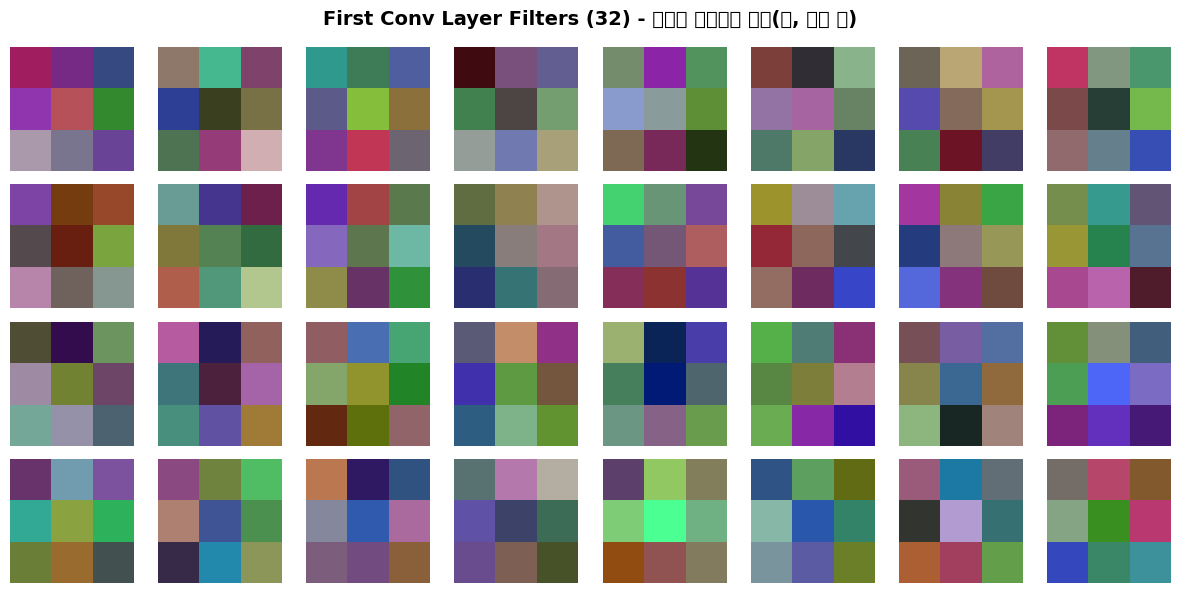

In [7]:
# [최적화 포인트 8: 필터 시각화 분석]
# 첫 번째 Conv 층의 가중치를 가져옵니다. (CPU로 다시 가져와야 그림을 그릴 수 있습니다)
weights = model.block1[0].weight.data.cpu()

# 가중치 값을 0~1 사이로 정규화 (색상으로 예쁘게 표현하기 위함)
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        # (채널, 높이, 너비) -> (높이, 너비, 채널) 순서로 변경하여 이미지 출력
        filt = weights[i].permute(1, 2, 0).numpy()
        ax.imshow(filt)
    ax.axis('off')

plt.suptitle("First Conv Layer Filters (32) - 모델이 집중하는 패턴(선, 질감 등)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 💡 보고서 꿀팁: "모델이 단순한 픽셀이 아니라 선, 모서리, 색상 대비 같은 의미 있는 특징(Feature)을
# 스스로 학습했음을 알 수 있습니다." 라고 적으시면 완벽합니다.

특징맵 시각화

/tmp/ipykernel_763/3756796851.py:31: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/3756796851.py:31: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_763/3756796851.py:31: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  fig.canv

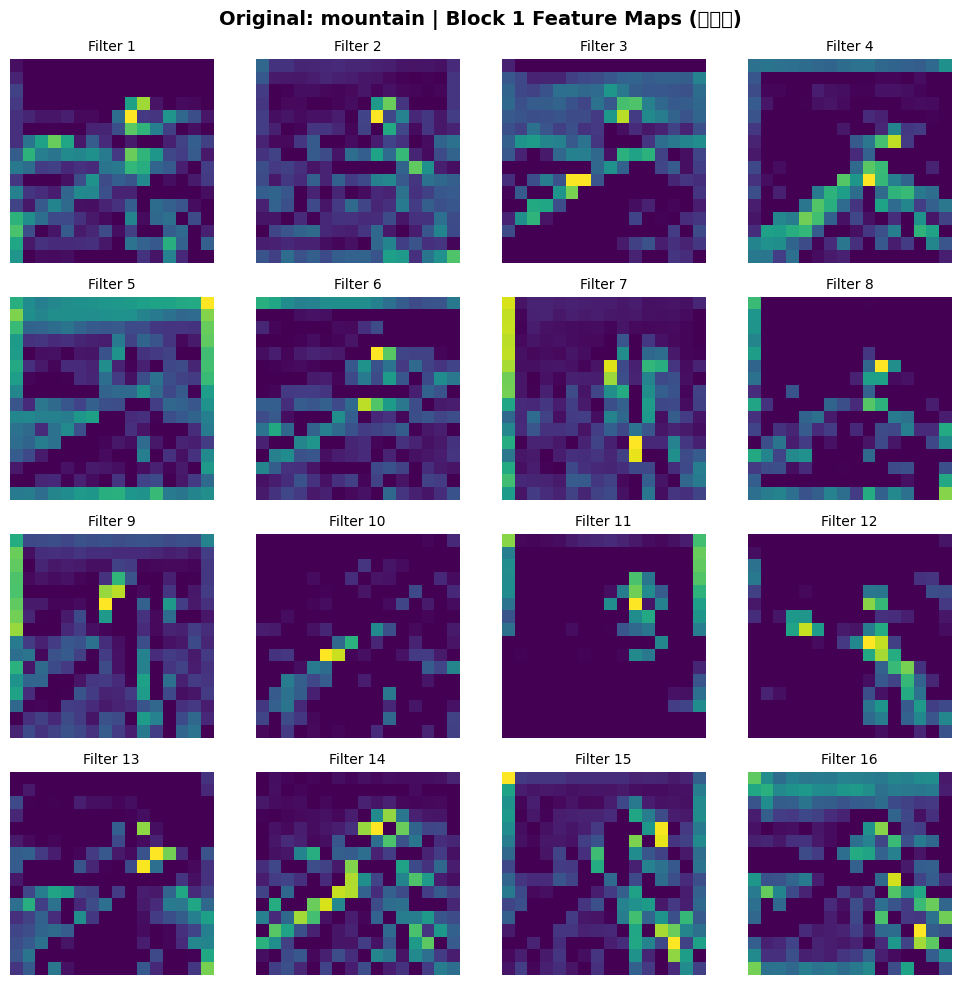

In [8]:
# [최적화 포인트 9: Forward Hook을 이용한 특징 추출]
# 테스트 데이터셋에서 첫 번째 사진을 가져와 우리가 설정한 만능 기기(device)에 올립니다.
image, label = test_dataset[0]
image_tensor = image.unsqueeze(0).to(device)

feature_maps = {}

# 모델의 특정 층(block1)을 통과할 때의 결과물을 가로채는(Hook) 함수
def hook_fn(module, input, output):
    feature_maps['block1'] = output.detach().cpu() # 결과물을 CPU로 가져옴

# 첫 번째 블록에 갈고리(Hook) 걸기
hook = model.block1.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    _ = model(image_tensor) # 사진을 모델에 통과시킴

hook.remove() # 다 썼으면 메모리를 위해 갈고리 제거!

# 뽑아낸 특징맵 그리기
fmaps = feature_maps['block1'][0]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < 16: # 32개 필터 중 16개만 확인
        ax.imshow(fmaps[i].numpy(), cmap='viridis')
        ax.set_title(f"Filter {i+1}", fontsize=10)
    ax.axis('off')

plt.suptitle(f"Original: {classes[label]} | Block 1 Feature Maps (특징맵)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

혼동 행렬

혼동 행렬을 그리기 위해 테스트 데이터를 분석 중입니다... 🕵️‍♂️


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

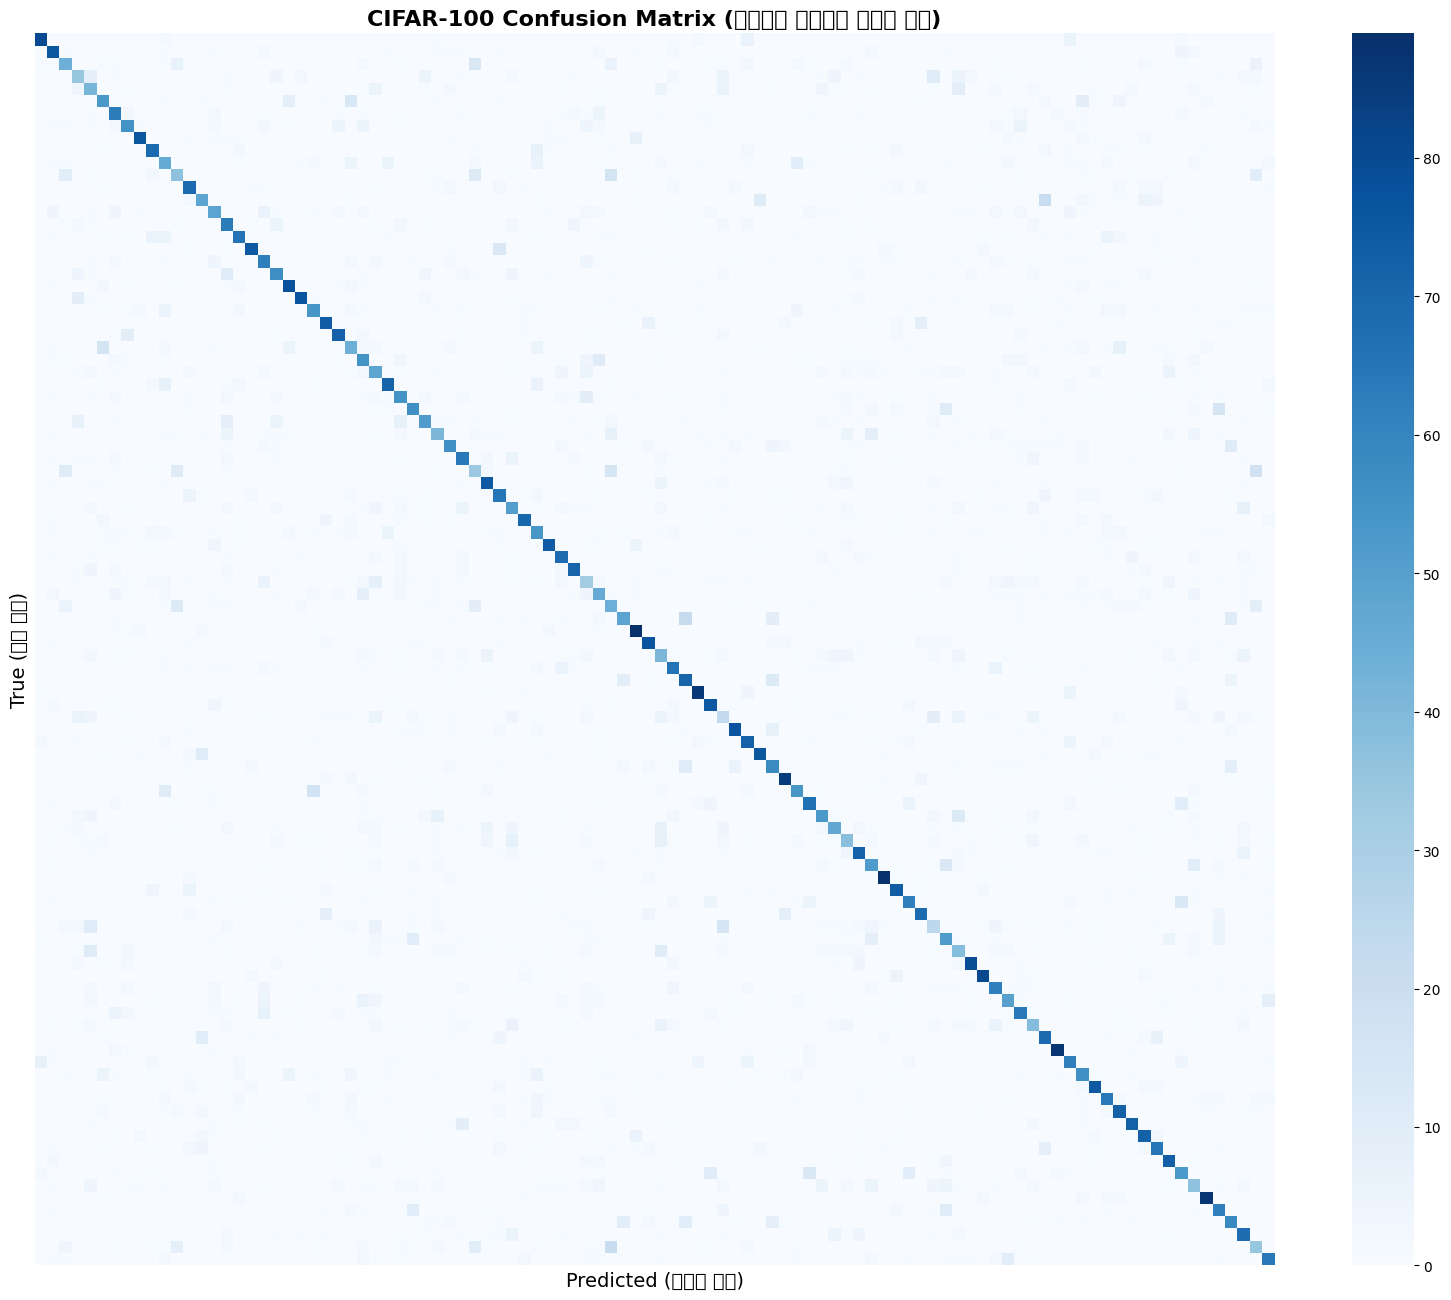

In [9]:
# [최적화 포인트 10: 전체 테스트 데이터 평가 및 약점 분석]
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()

print("혼동 행렬을 그리기 위해 테스트 데이터를 분석 중입니다... 🕵️‍♂️")
with torch.no_grad():
    for images, labels in test_loader:
        # 이미지를 GPU/MPS 등에 올리고 예측
        outputs = model(images.to(device))
        preds = outputs.max(1)[1].cpu() # 결과는 다시 CPU로!

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# 혼동 행렬 생성
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 16))
# 100개 클래스라 글씨가 많아지면 지저분하므로 숫자는 숨김(annot=False)
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=False, yticklabels=False)
plt.xlabel('Predicted (모델의 예측)', fontsize=14)
plt.ylabel('True (실제 정답)', fontsize=14)
plt.title('CIFAR-100 Confusion Matrix (대각선이 진할수록 성능이 좋음)', fontsize=16, fontweight='bold')
plt.show()

임의의 사진 입력 및 예측 검증

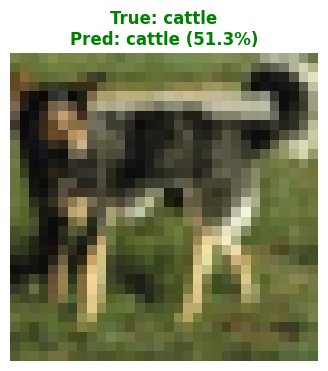

🎉 정답입니다! 모델이 51.3%의 확신으로 맞췄습니다.


In [15]:
# [최적화 포인트 11: 실전 추론(Inference) 테스트]
import random

def predict_random_cifar_image(model, dataset, device, classes):
    model.eval() # 평가 모드로 전환

    # 1. 무작위로 사진 하나 뽑기
    idx = random.randint(0, len(dataset) - 1)
    image_tensor, true_label_idx = dataset[idx]
    true_class = classes[true_label_idx]

    # 2. 모델에 입력하기 위해 차원 추가 후 장치에 올리기 [채널, 높이, 너비] -> [1, 채널, 높이, 너비]
    img_input = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_input)
        # 3. Softmax를 통과시켜 100개 클래스에 대한 각각의 '확률'을 계산
        probabilities = F.softmax(output[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, dim=0)

    predicted_class = classes[predicted_idx.item()]
    confidence_score = confidence.item() * 100 # 자신감(확률) 퍼센트

    # 4. 사람이 볼 수 있게 정규화(Normalize)된 이미지를 원래 색상으로 되돌리기
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)
    img_show = image_tensor.cpu() * std + mean

    # 색상 범위를 0~1로 맞추고 (높이, 너비, 채널)로 변경
    img_show = img_show.clamp(0, 1).permute(1, 2, 0).numpy()

    # 5. 결과 출력
    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)

    # 맞췄으면 초록색, 틀렸으면 빨간색으로 제목 표시
    title_color = 'green' if true_class == predicted_class else 'red'
    plt.title(f"True: {true_class}\nPred: {predicted_class} ({confidence_score:.1f}%)",
              color=title_color, fontweight='bold')
    plt.axis('off')
    plt.show()

    if true_class == predicted_class:
        print(f"🎉 정답입니다! 모델이 {confidence_score:.1f}%의 확신으로 맞췄습니다.")
    else:
        print(f"😢 아쉽게 틀렸습니다. (실제: {true_class} / 예측: {predicted_class})")

# 이 함수를 실행할 때마다 랜덤한 테스트 사진이 나옵니다!
# 셀을 여러 번 실행하면서 모델의 성능을 재미있게 테스트해 보세요.
predict_random_cifar_image(model, test_dataset, device, classes)